In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ορίζουμε το στυλ για τα γραφήματα
sns.set_theme(style="whitegrid")

df = pd.read_csv('main.csv')
# 1. Έλεγχος για κενά (Missing Values)
print(df.isnull().sum() / len(df) * 100) # Βλέπουμε το % των NaNs ανά στήλη

# 2. Διαχείριση Missing Values στα Labs
# Επειδή οι ιατρικές μετρήσεις έχουν συχνά ασύμμετρη κατανομή (skewed),
# το median είναι πολύ πιο ασφαλές από το mean.
lab_columns = ['alt', 'ast', 'creatinine', 'platelets', 'glucose']
for col in lab_columns:
    df[col] = df[col].fillna(df[col].median())

# 3. Διαχείριση Outliers (Clipping)
# Αντί να πετάξουμε γραμμές, "κόβουμε" τα ακραία 1% και 99% 
# για να μην καταστρέψουν τα μοντέλα μας.
for col in lab_columns:
    lower_limit = df[col].quantile(0.01)
    upper_limit = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=lower_limit, upper=upper_limit)

# 4. Drop διπλότυπων (καλού κακού)
df = df.drop_duplicates(subset=['hadm_id'])

subject_id       0.0
hadm_id          0.0
gender           0.0
age              0.0
icd9_code        0.0
short_title      0.0
long_title       0.0
liver_group      0.0
ast              0.0
alt              0.0
ast_alt_ratio    0.0
bilirubin        0.0
albumin          0.0
platelets        0.0
inr              0.0
creatinine       0.0
glucose          0.0
fib4_score       0.0
dtype: float64


C:\Users\pkiaz\AppData\Local\Temp\ipykernel_7832\654556359.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='gender', ax=axes[1], palette='Set2')
C:\Users\pkiaz\AppData\Local\Temp\ipykernel_7832\654556359.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='liver_group', ax=axes[2], palette='Set1',


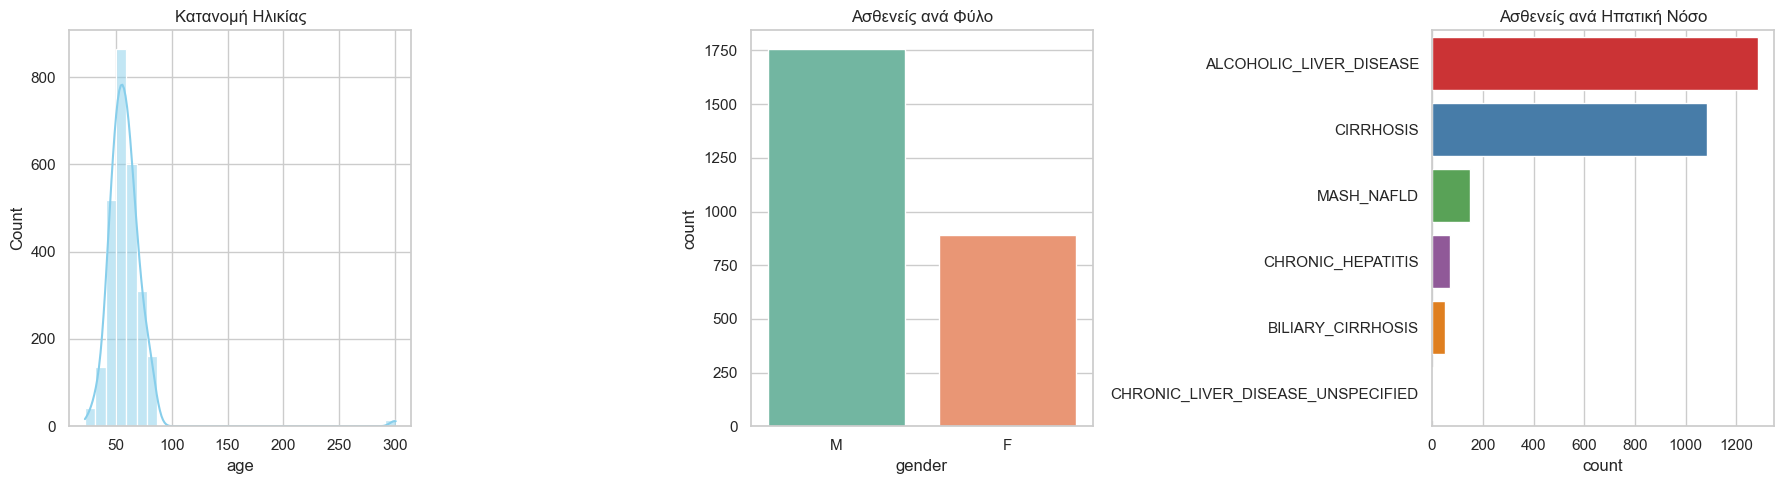

In [4]:
sns.set_theme(style="whitegrid")

# Φτιάχνουμε τον καμβά για 3 γραφήματα δίπλα δίπλα
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Ηλικιακή κατανομή (Αυτό δούλευε ήδη)
sns.histplot(data=df, x='age', bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Κατανομή Ηλικίας')

# 2. Κατανομή Φύλου (Αντικαθιστά τον διαβήτη που λείπει)
sns.countplot(data=df, x='gender', ax=axes[1], palette='Set2')
axes[1].set_title('Ασθενείς ανά Φύλο')

# 3. Ισορροπία Ηπατικής Νόσου (Η σωστή στήλη είναι liver_group)
# Το κάνουμε y='liver_group' ώστε τα ονόματα των ασθενειών να είναι οριζόντια και να διαβάζονται
sns.countplot(data=df, y='liver_group', ax=axes[2], palette='Set1', 
              order=df['liver_group'].value_counts().index)
axes[2].set_title('Ασθενείς ανά Ηπατική Νόσο')
axes[2].set_ylabel('') # Κρύβουμε τον τίτλο του άξονα Y για να είναι πιο καθαρό

plt.tight_layout()
plt.show()

In [5]:
# --- Εκτύπωση Στατιστικών για τις Κλάσεις ---

# 1. Πόσες είναι οι διαφορετικές κλάσεις (ομάδες) συνολικά;
num_classes = df['liver_group'].nunique()
print(f"Συνολικός αριθμός κλάσεων (Ηπατικών Νοσημάτων): {num_classes}\n")

# 2. Πόσοι ασθενείς ανήκουν στην κάθε κλάση;
class_counts = df['liver_group'].value_counts()
print("Αριθμός ασθενών ανά κλάση (Απόλυτα Νούμερα):")
print("-" * 45)
print(class_counts.to_string()) # Χρησιμοποιούμε to_string() για πιο καθαρή εκτύπωση

print("\n")

# 3. Ποιο είναι το ποσοστό (%) της κάθε κλάσης στο συνολικό δείγμα;
class_percentages = df['liver_group'].value_counts(normalize=True) * 100
print("Ποσοστό (%) ασθενών ανά κλάση:")
print("-" * 45)
# Στρογγυλοποιούμε στα 2 δεκαδικά και προσθέτουμε το σύμβολο %
print(class_percentages.round(2).astype(str) + " %")

Συνολικός αριθμός κλάσεων (Ηπατικών Νοσημάτων): 6

Αριθμός ασθενών ανά κλάση (Απόλυτα Νούμερα):
---------------------------------------------
liver_group
ALCOHOLIC_LIVER_DISEASE              1284
CIRRHOSIS                            1085
MASH_NAFLD                            150
CHRONIC_HEPATITIS                      72
BILIARY_CIRRHOSIS                      49
CHRONIC_LIVER_DISEASE_UNSPECIFIED       5


Ποσοστό (%) ασθενών ανά κλάση:
---------------------------------------------
liver_group
ALCOHOLIC_LIVER_DISEASE              48.54 %
CIRRHOSIS                            41.02 %
MASH_NAFLD                            5.67 %
CHRONIC_HEPATITIS                     2.72 %
BILIARY_CIRRHOSIS                     1.85 %
CHRONIC_LIVER_DISEASE_UNSPECIFIED     0.19 %
Name: proportion, dtype: object


Ασθενείς ανά Cluster στη MASH:
cluster
Cluster 0    144
Cluster 2      4
Cluster 1      2
Name: count, dtype: int64



C:\Users\pkiaz\AppData\Local\Temp\ipykernel_7832\4017720323.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_mash, x='cluster', y='fib4_score', ax=axes[0], palette='pastel')
C:\Users\pkiaz\AppData\Local\Temp\ipykernel_7832\4017720323.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_mash, x='cluster', y='ast', ax=axes[1], palette='pastel')
C:\Users\pkiaz\AppData\Local\Temp\ipykernel_7832\4017720323.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_mash, x='cluster', y='platelets', ax=axes[2], palette='pastel

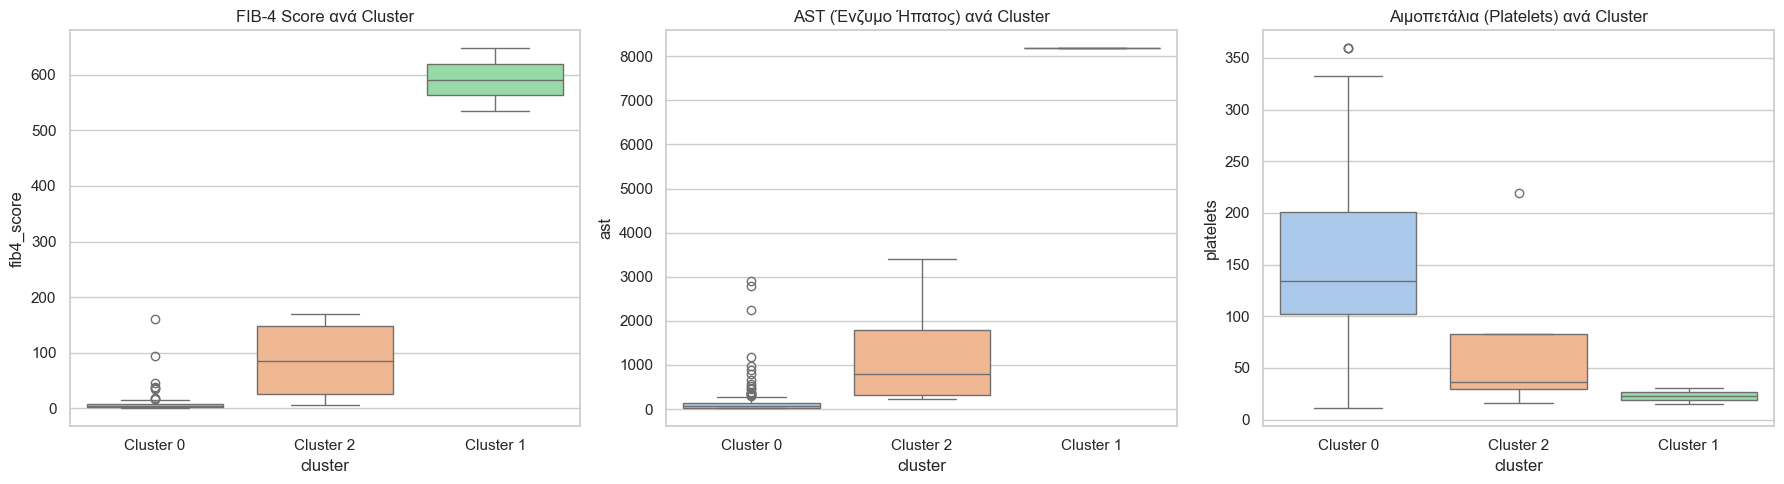

In [6]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Επιλέγουμε μόνο τους ασθενείς με MASH/NAFLD
df_mash = df[df['liver_group'] == 'MASH_NAFLD'].copy()

# 2. Επιλέγουμε τα εργαστηριακά που θέλουμε να δει ο αλγόριθμος
features_for_clustering = ['ast', 'alt', 'platelets', 'fib4_score', 'glucose', 'bilirubin']
X_cluster = df_mash[features_for_clustering]

# 3. Κανονικοποίηση (Standard Scaling) - ΥΠΕΡΒΟΛΙΚΑ ΣΗΜΑΝΤΙΚΟ!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# 4. Εφαρμογή K-Means με 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_mash['cluster'] = kmeans.fit_predict(X_scaled)

# Ονομάζουμε τα clusters για να φαίνονται ωραία στα γραφήματα
df_mash['cluster'] = df_mash['cluster'].map({0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2'})

print(f"Ασθενείς ανά Cluster στη MASH:\n{df_mash['cluster'].value_counts()}\n")

# --- 5. Ερμηνεία με Boxplots ---
# Θα δούμε πώς διαφέρουν 3 βασικά χαρακτηριστικά (FIB-4, AST, Platelets) ανά Cluster
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.set_theme(style="whitegrid")

# Γράφημα 1: FIB-4 Score (Δείκτης Ίνωσης / Ζημιάς)
sns.boxplot(data=df_mash, x='cluster', y='fib4_score', ax=axes[0], palette='pastel')
axes[0].set_title('FIB-4 Score ανά Cluster')

# Γράφημα 2: AST (Δείκτης ενεργής φλεγμονής)
sns.boxplot(data=df_mash, x='cluster', y='ast', ax=axes[1], palette='pastel')
axes[1].set_title('AST (Ένζυμο Ήπατος) ανά Cluster')

# Γράφημα 3: Αιμοπετάλια (Platelets - Πέφτουν όσο χαλάει το συκώτι)
sns.boxplot(data=df_mash, x='cluster', y='platelets', ax=axes[2], palette='pastel')
axes[2].set_title('Αιμοπετάλια (Platelets) ανά Cluster')

plt.tight_layout()
plt.show()

C:\Users\pkiaz\AppData\Local\Temp\ipykernel_7832\1825653199.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_mash, x='cluster', y='fib4_score', ax=axes[0], palette='pastel')
C:\Users\pkiaz\AppData\Local\Temp\ipykernel_7832\1825653199.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_mash, x='cluster', y='ast', ax=axes[1], palette='pastel')
C:\Users\pkiaz\AppData\Local\Temp\ipykernel_7832\1825653199.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_mash, x='cluster', y='platelets', ax=axes[2], palette='pastel'

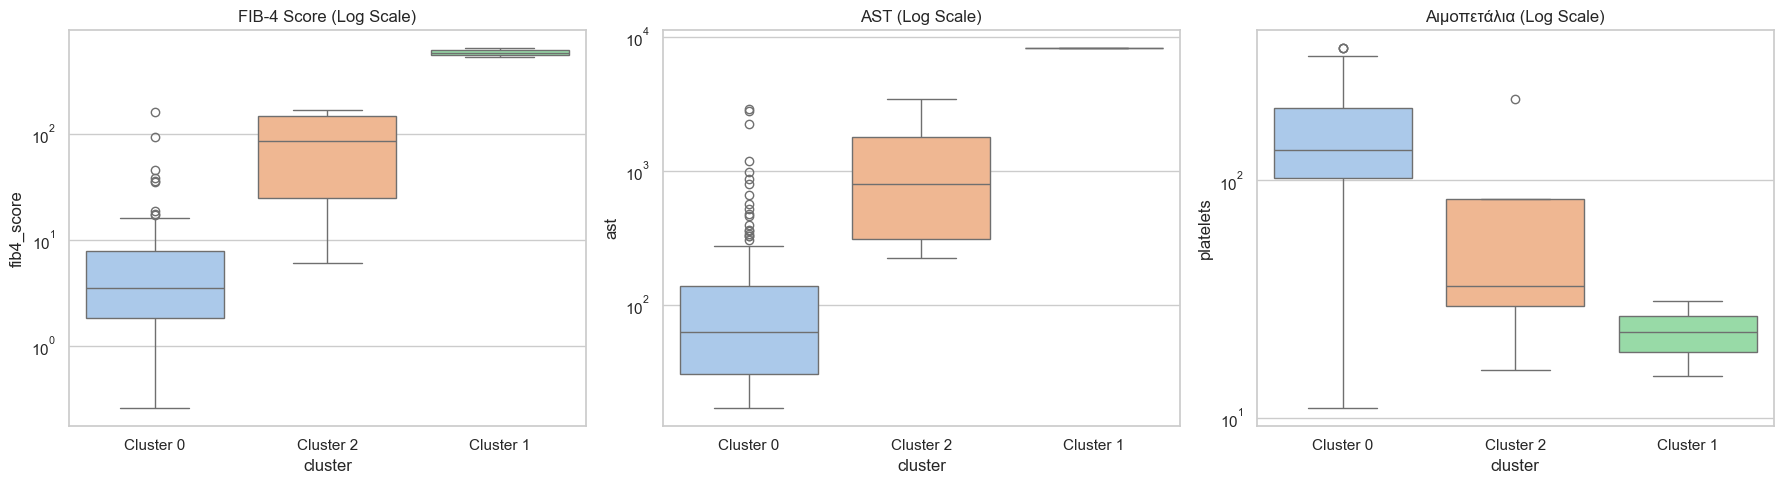

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.set_theme(style="whitegrid")

# Γράφημα 1: FIB-4 Score
sns.boxplot(data=df_mash, x='cluster', y='fib4_score', ax=axes[0], palette='pastel')
axes[0].set_title('FIB-4 Score (Log Scale)')
axes[0].set_yscale('log') # <-- Η μαγική γραμμή

# Γράφημα 2: AST
sns.boxplot(data=df_mash, x='cluster', y='ast', ax=axes[1], palette='pastel')
axes[1].set_title('AST (Log Scale)')
axes[1].set_yscale('log') # <-- Η μαγική γραμμή

# Γράφημα 3: Αιμοπετάλια
sns.boxplot(data=df_mash, x='cluster', y='platelets', ax=axes[2], palette='pastel')
axes[2].set_title('Αιμοπετάλια (Log Scale)')
axes[2].set_yscale('log') # <-- Η μαγική γραμμή

plt.tight_layout()
plt.show()

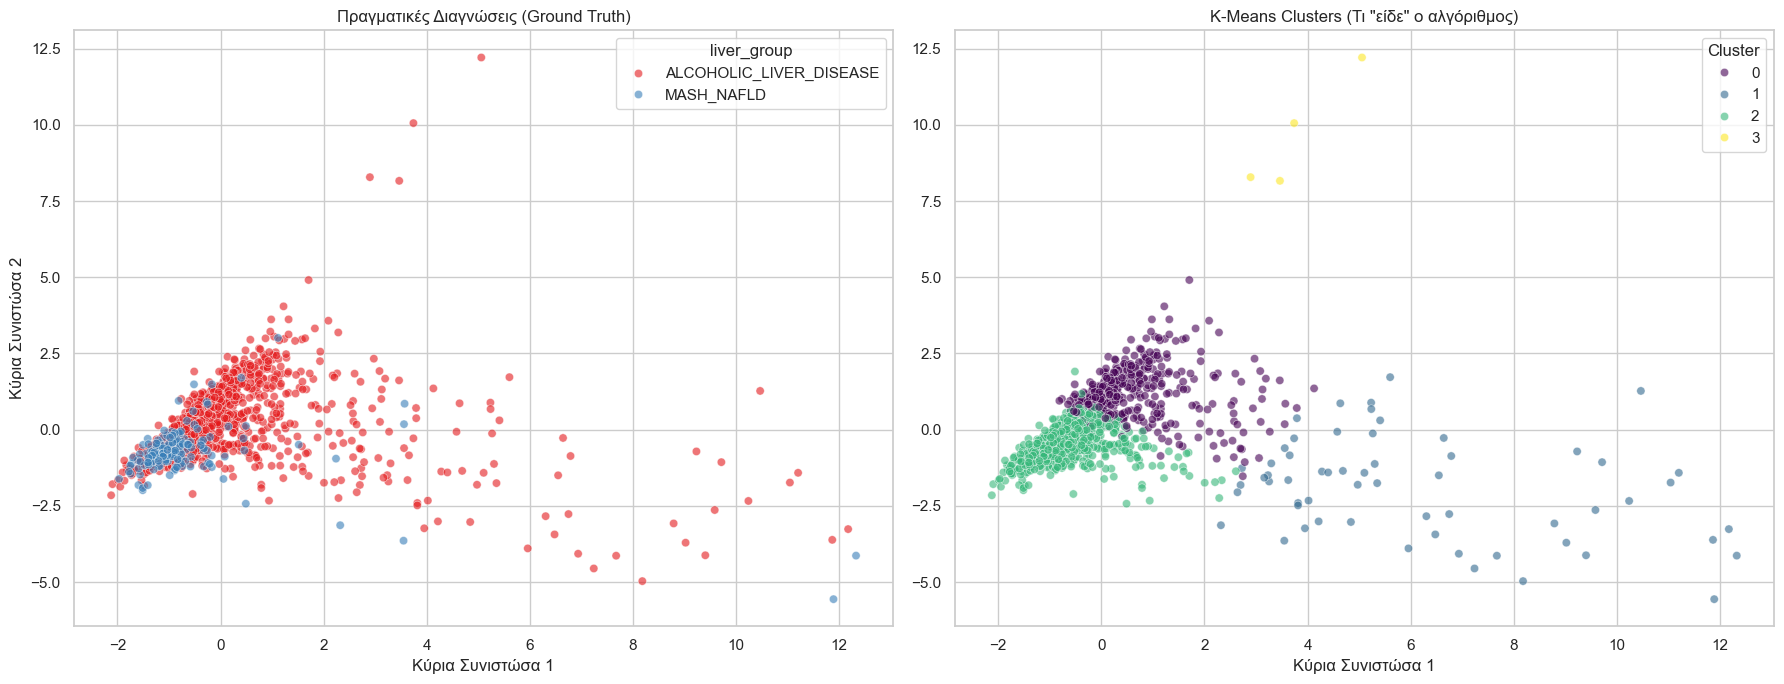

Πίνακας Αντιστοίχισης: Clusters vs Πραγματικές Διαγνώσεις
-----------------------------------------------------------------
Cluster                    0   1    2  3
liver_group                             
ALCOHOLIC_LIVER_DISEASE  382  55  843  4
MASH_NAFLD                13   4  133  0


In [9]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Κρατάμε τις 4 κυρίαρχες κλάσεις για να μην έχουμε θόρυβο
top_4 = ['ALCOHOLIC_LIVER_DISEASE', 'AUTOIMMUNE_LIVER_DISEASE', 'ACUTE_LIVER_FAILURE', 'MASH_NAFLD']
df_eda = df[df['liver_group'].isin(top_4)].copy()

# 2. Ορίζουμε τα εργαστηριακά χαρακτηριστικά
features = ['ast', 'alt', 'platelets', 'fib4_score', 'glucose', 'bilirubin', 'age', 'inr', 'creatinine']
X_eda = df_eda[features]

# 3. Κανονικοποίηση (Standard Scaling) - ΑΠΑΡΑΙΤΗΤΟ για PCA και K-Means
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_eda)

# --- ΤΕΧΝΙΚΗ 1: PCA (Μείωση Διαστάσεων για Οπτικοποίηση) ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Αποθηκεύουμε τις 2 νέες συντεταγμένες στο dataframe
df_eda['PCA_1'] = X_pca[:, 0]
df_eda['PCA_2'] = X_pca[:, 1]

# --- ΤΕΧΝΙΚΗ 2: K-Means Clustering ---
# Ψάχνουμε 4 clusters (όσες και οι ασθένειες)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_eda['Cluster'] = kmeans.fit_predict(X_scaled)

# --- ΟΠΤΙΚΟΠΟΙΗΣΗ ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.set_theme(style="whitegrid")

# Γράφημα Α: Τα Πραγματικά Δεδομένα (Βάσει Διάγνωσης Γιατρού)
sns.scatterplot(data=df_eda, x='PCA_1', y='PCA_2', hue='liver_group', 
                palette='Set1', alpha=0.6, ax=axes[0])
axes[0].set_title('Πραγματικές Διαγνώσεις (Ground Truth)')
axes[0].set_xlabel('Κύρια Συνιστώσα 1')
axes[0].set_ylabel('Κύρια Συνιστώσα 2')

# Γράφημα Β: Τα Clusters που βρήκε ο Αλγόριθμος (Τυφλά)
sns.scatterplot(data=df_eda, x='PCA_1', y='PCA_2', hue='Cluster', 
                palette='viridis', alpha=0.6, ax=axes[1])
axes[1].set_title('K-Means Clusters (Τι "είδε" ο αλγόριθμος)')
axes[1].set_xlabel('Κύρια Συνιστώσα 1')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# --- ΑΞΙΟΛΟΓΗΣΗ CLUSTERING ---
print("Πίνακας Αντιστοίχισης: Clusters vs Πραγματικές Διαγνώσεις")
print("-" * 65)
crosstab = pd.crosstab(df_eda['liver_group'], df_eda['Cluster'])
print(crosstab)

In [10]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import plotly.express as px
import pandas as pd

# 1. Κρατάμε τις 4 κυρίαρχες κλάσεις
top_4 = ['ALCOHOLIC_LIVER_DISEASE', 'AUTOIMMUNE_LIVER_DISEASE', 'ACUTE_LIVER_FAILURE', 'MASH_NAFLD']
df_3d = df[df['liver_group'].isin(top_4)].copy()

# 2. Ορίζουμε τα χαρακτηριστικά και κανονικοποιούμε (Standardization)
features = ['ast', 'alt', 'platelets', 'fib4_score', 'glucose', 'bilirubin', 'age', 'inr', 'creatinine']
X_3d = df_3d[features]

scaler = StandardScaler()
X_scaled_3d = scaler.fit_transform(X_3d)

# 3. Εφαρμογή PCA για 3 ΔΙΑΣΤΑΣΕΙΣ (n_components=3)
pca_3d = PCA(n_components=3)
components_3d = pca_3d.fit_transform(X_scaled_3d)

# 4. Βάζουμε τις νέες συντεταγμένες πίσω στο dataframe
df_3d['PCA_1'] = components_3d[:, 0]
df_3d['PCA_2'] = components_3d[:, 1]
df_3d['PCA_3'] = components_3d[:, 2]

# Πόση πληροφορία κρατήσαμε συνολικά;
explained_variance = sum(pca_3d.explained_variance_ratio_) * 100
print(f"Με 3 διαστάσεις κρατήσαμε το {explained_variance:.2f}% της αρχικής πληροφορίας των εξετάσεων!\n")

# 5. Σχεδιασμός Διαδραστικού 3D Γραφήματος με Plotly
fig = px.scatter_3d(
    df_3d, 
    x='PCA_1', 
    y='PCA_2', 
    z='PCA_3',
    color='liver_group',
    opacity=0.7,
    title='3D PCA: Διαχωρισμός Ηπατικών Νοσημάτων',
    labels={'PCA_1': 'Κύρια Συνιστώσα 1', 'PCA_2': 'Κύρια Συνιστώσα 2', 'PCA_3': 'Κύρια Συνιστώσα 3'},
    color_discrete_sequence=px.colors.qualitative.Set1
)

Με 3 διαστάσεις κρατήσαμε το 58.61% της αρχικής πληροφορίας των εξετάσεων!



In [13]:
# Κάνουμε τις "μπίλιες" λίγο πιο μικρές για να μη γεμίσει η οθόνη
fig.update_traces(marker=dict(size=4))

# Εμφάνιση του γραφήματος
fig.show()

In [14]:
# --- ΠΡΟΣΘΗΚΗ ΝΕΩΝ ΙΑΤΡΙΚΩΝ FEATURES ΣΤΟ DF ---

# 1. APRI Score
# Υποθέτουμε το 40 ως το Upper Limit of Normal (ULN) για το AST
df['apri_score'] = (df['ast'] / 40.0) / df['platelets'] * 100

# 2. Μεταβολικός Κίνδυνος (Ιδιαίτερα χρήσιμο για τη MASH)
# Δίνει 1 αν ισχύουν και τα δύο (υψηλό ζάχαρο & ηλικία > 50), αλλιώς 0
df['metabolic_risk'] = ((df['glucose'] > 100) & (df['age'] > 50)).astype(int)

# 3. Δείκτης Σοβαρότητας (Bilirubin x INR)
df['severity_proxy'] = df['bilirubin'] * df['inr']

# --- ΕΝΗΜΕΡΩΣΗ ΤΗΣ ΛΙΣΤΑΣ ΤΩΝ FEATURES ---
# Τώρα προσθέτουμε τις νέες στήλες στη λίστα που θα δώσουμε στο μοντέλο
features = [
    'ast', 'alt', 'ast_alt_ratio', 'platelets', 'fib4_score', 
    'glucose', 'bilirubin', 'age', 'inr', 'has_thrombocytopenia', 'is_senior',
    'apri_score', 'metabolic_risk', 'severity_proxy'  # <--- Τα νέα μας features!
]


In [18]:
df_binary = df[df['liver_group'].isin(['ALCOHOLIC_LIVER_DISEASE', 'MASH_NAFLD'])].copy()

print(f"Εκπαίδευση σε {len(df_binary)} ασθενείς (Αλκοολικούς & MASH).")

# 2. FEATURE ENGINEERING (Προσθήκη νέων στηλών στο df_binary)
df_binary['has_thrombocytopenia'] = (df_binary['platelets'] < 150).astype(int)
df_binary['is_senior'] = (df_binary['age'] >= 60).astype(int)
df_binary['apri_score'] = (df_binary['ast'] / 40.0) / df_binary['platelets'] * 100
df_binary['metabolic_risk'] = ((df_binary['glucose'] > 100) & (df_binary['age'] > 50)).astype(int)
df_binary['severity_proxy'] = df_binary['bilirubin'] * df_binary['inr']

# 3. Επιλογή των Χαρακτηριστικών (X) και της Ασθένειας (y)
features = [
    'ast', 'alt', 'ast_alt_ratio', 'platelets', 'fib4_score', 
    'glucose', 'bilirubin', 'age', 'inr', 
    'has_thrombocytopenia', 'is_senior', 'apri_score', 'metabolic_risk', 'severity_proxy'
]

X = df_binary[features]
y_text = df_binary['liver_group']

# 4. Μετατροπή των λέξεων σε 0 και 1 (Απαραίτητο για XGBoost)
le = LabelEncoder()
y = le.fit_transform(y_text)

# 5. Εκπαίδευση XGBoost με 5-Fold Cross Validation
xgb_model = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42, eval_metric='logloss')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\nΤρέχει το μοντέλο XGBoost...")
scores = cross_val_score(xgb_model, X, y, cv=cv, scoring='accuracy')

# 6. Εμφάνιση Αποτελεσμάτων
for i, score in enumerate(scores):
    print(f"Γύρος {i+1}: Ακρίβεια = {score*100:.2f}%")

print(f"\nΤελική Ακρίβεια (Μέσος Όρος): {scores.mean()*100:.2f}%")

Εκπαίδευση σε 1434 ασθενείς (Αλκοολικούς & MASH).

Τρέχει το μοντέλο XGBoost...
Γύρος 1: Ακρίβεια = 90.94%
Γύρος 2: Ακρίβεια = 91.64%
Γύρος 3: Ακρίβεια = 91.64%
Γύρος 4: Ακρίβεια = 91.64%
Γύρος 5: Ακρίβεια = 88.81%

Τελική Ακρίβεια (Μέσος Όρος): 90.93%


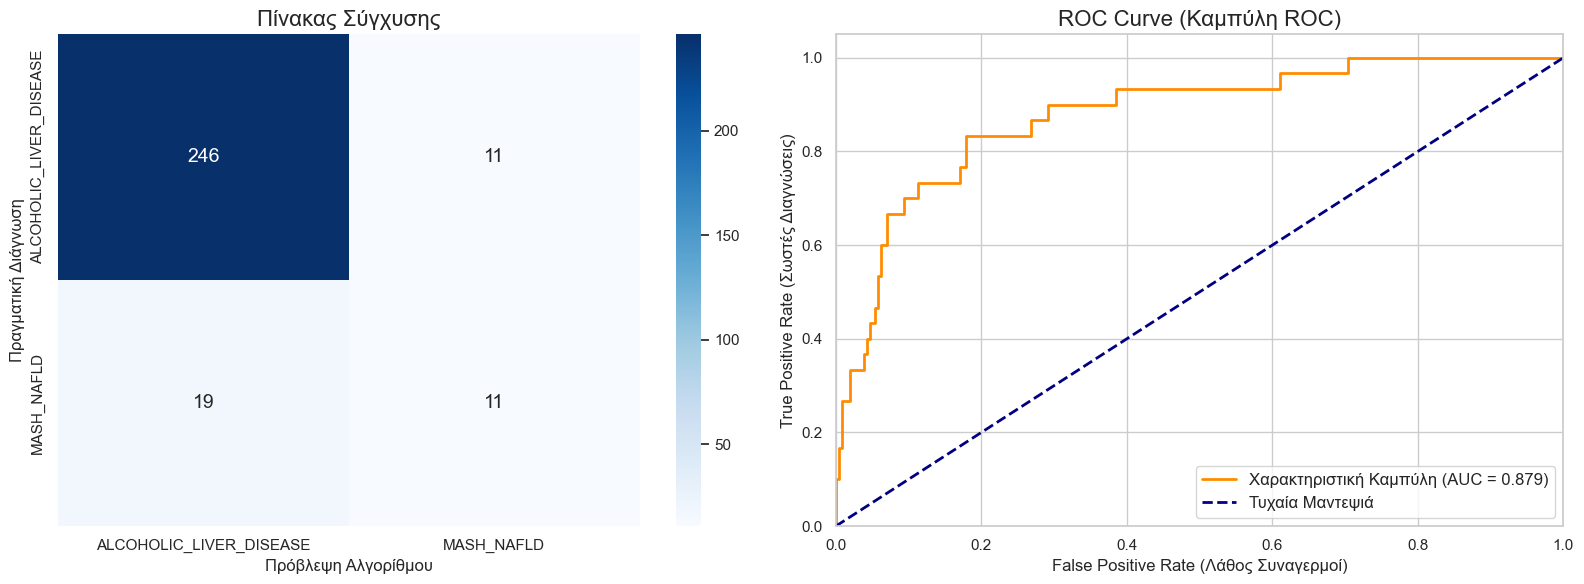

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split

# 1. Κρατάμε 20% των ασθενών καθαρά για το Test (Τελική Εξέταση)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Εκπαιδεύουμε το τελικό μας μοντέλο
xgb_model.fit(X_train, y_train)

# 3. Προβλέψεις
# Το .predict δίνει το απόλυτο 0 ή 1 (Αλκοολικός ή MASH)
y_pred = xgb_model.predict(X_test)         
# Το .predict_proba δίνει την % πιθανότητα (π.χ. 85% MASH) - Το χρειαζόμαστε για τη ROC!
y_probs = xgb_model.predict_proba(X_test)[:, 1] 

# --- ΦΤΙΑΧΝΟΥΜΕ ΤΟΝ ΚΑΜΒΑ ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- ΓΡΑΦΗΜΑ 1: CONFUSION MATRIX ---
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=le.classes_, yticklabels=le.classes_, annot_kws={"size": 14})
axes[0].set_title('Πίνακας Σύγχυσης', fontsize=16)
axes[0].set_ylabel('Πραγματική Διάγνωση', fontsize=12)
axes[0].set_xlabel('Πρόβλεψη Αλγορίθμου', fontsize=12)

# --- ΓΡΑΦΗΜΑ 2: ROC CURVE ---
# Υπολογισμός των σημείων της καμπύλης
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr) # Υπολογισμός του Area Under Curve (AUC)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'Χαρακτηριστική Καμπύλη (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Τυχαία Μαντεψιά') 
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (Λάθος Συναγερμοί)', fontsize=12)
axes[1].set_ylabel('True Positive Rate (Σωστές Διαγνώσεις)', fontsize=12)
axes[1].set_title('ROC Curve (Καμπύλη ROC)', fontsize=16)
axes[1].legend(loc="lower right", fontsize=12)

plt.tight_layout()
plt.show()

C:\Users\pkiaz\AppData\Local\Temp\ipykernel_7832\4141223653.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




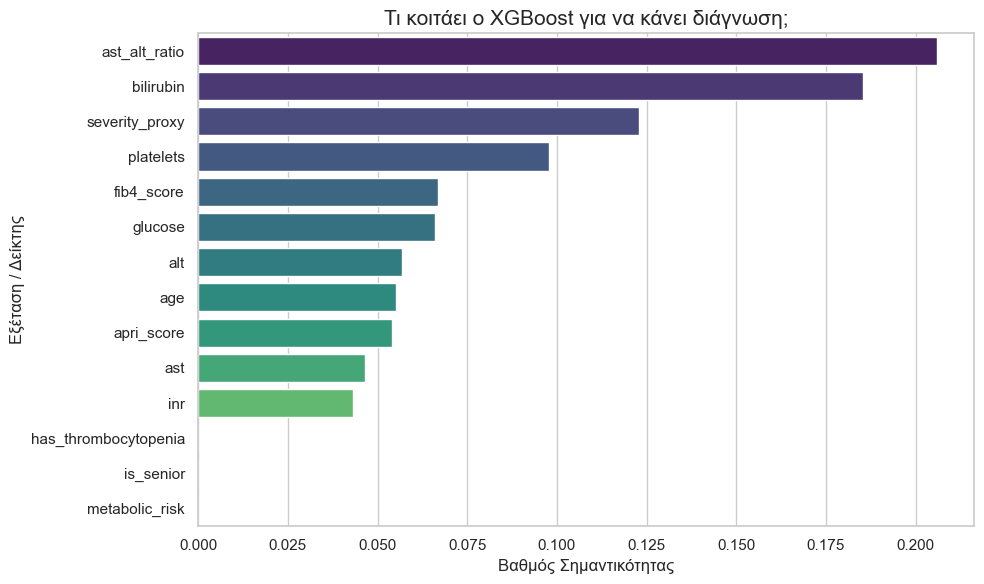

In [24]:
importances = xgb_model.feature_importances_
fi_df = pd.DataFrame({
    'Feature': features, 
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
sns.barplot(data=fi_df, x='Importance', y='Feature', palette='viridis')

plt.title('Τι κοιτάει ο XGBoost για να κάνει διάγνωση;', fontsize=15)
plt.xlabel('Βαθμός Σημαντικότητας', fontsize=12)
plt.ylabel('Εξέταση / Δείκτης', fontsize=12)
plt.tight_layout()
plt.show()

In [20]:
from sklearn.metrics import classification_report

print("--- ΑΝΑΛΥΤΙΚΗ ΑΝΑΦΟΡΑ ΤΑΞΙΝΟΜΗΣΗΣ (CLASSIFICATION REPORT) ---")
# Χρησιμοποιούμε το le.classes_ για να μας τυπώσει τα κανονικά ονόματα των ασθενειών αντί για 0 και 1
print(classification_report(y_test, y_pred, target_names=le.classes_))

--- ΑΝΑΛΥΤΙΚΗ ΑΝΑΦΟΡΑ ΤΑΞΙΝΟΜΗΣΗΣ (CLASSIFICATION REPORT) ---
                         precision    recall  f1-score   support

ALCOHOLIC_LIVER_DISEASE       0.93      0.96      0.94       257
             MASH_NAFLD       0.50      0.37      0.42        30

               accuracy                           0.90       287
              macro avg       0.71      0.66      0.68       287
           weighted avg       0.88      0.90      0.89       287



In [21]:
import numpy as np

# 1. Πραγματικοί Ασθενείς (Τι έλεγε ο φάκελος του γιατρού)
unique_true, counts_true = np.unique(y_test, return_counts=True)
print("--- ΠΡΑΓΜΑΤΙΚΟΙ ΑΣΘΕΝΕΙΣ ΣΤΟ TEST SET ---")
for cls_num, count in zip(unique_true, counts_true):
    # Το le.inverse_transform μετατρέπει ξανά το 0 και 1 σε κείμενο (π.χ. MASH)
    disease_name = le.inverse_transform([cls_num])[0]
    print(f"- {disease_name}: {count} άτομα")

print("\n")

# 2. Προβλέψεις Αλγορίθμου (Τι μάντεψε το XGBoost)
unique_preds, counts_preds = np.unique(y_pred, return_counts=True)
print("--- ΠΡΟΒΛΕΨΕΙΣ ΑΛΓΟΡΙΘΜΟΥ (XGBoost) ---")
for cls_num, count in zip(unique_preds, counts_preds):
    disease_name = le.inverse_transform([cls_num])[0]
    print(f"- {disease_name}: {count} άτομα")

--- ΠΡΑΓΜΑΤΙΚΟΙ ΑΣΘΕΝΕΙΣ ΣΤΟ TEST SET ---
- ALCOHOLIC_LIVER_DISEASE: 257 άτομα
- MASH_NAFLD: 30 άτομα


--- ΠΡΟΒΛΕΨΕΙΣ ΑΛΓΟΡΙΘΜΟΥ (XGBoost) ---
- ALCOHOLIC_LIVER_DISEASE: 265 άτομα
- MASH_NAFLD: 22 άτομα


--- ΑΝΑΦΟΡΑ ΤΑΞΙΝΟΜΗΣΗΣ (RANDOM FOREST) ---
                         precision    recall  f1-score   support

ALCOHOLIC_LIVER_DISEASE       0.93      0.88      0.90       292
             MASH_NAFLD       0.39      0.54      0.45        41

               accuracy                           0.84       333
              macro avg       0.66      0.71      0.68       333
           weighted avg       0.86      0.84      0.85       333





C:\Users\pkiaz\AppData\Local\Temp\ipykernel_7832\1273469798.py:59: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




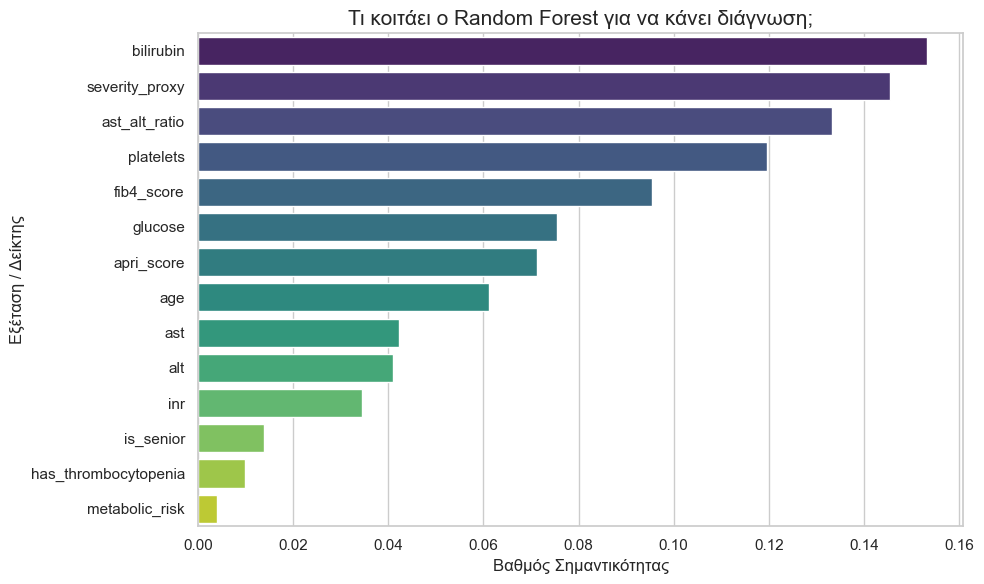

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

# 1. Φόρτωση & Προετοιμασία (Κρατάμε μόνο Αλκοολικούς και MASH)
df = pd.read_csv('main.csv')
df_binary = df[df['liver_group'].isin(['ALCOHOLIC_LIVER_DISEASE', 'MASH_NAFLD'])].copy()

# 2. Feature Engineering (Οι "έξυπνες" ιατρικές στήλες μας)
df_binary['has_thrombocytopenia'] = (df_binary['platelets'] < 150).astype(int)
df_binary['is_senior'] = (df_binary['age'] >= 60).astype(int)
df_binary['apri_score'] = (df_binary['ast'] / 40.0) / df_binary['platelets'] * 100
df_binary['metabolic_risk'] = ((df_binary['glucose'] > 100) & (df_binary['age'] > 50)).astype(int)
df_binary['severity_proxy'] = df_binary['bilirubin'] * df_binary['inr']

# 3. Ορισμός των μεταβλητών (X) και του Στόχου (y)
features = [
    'ast', 'alt', 'ast_alt_ratio', 'platelets', 'fib4_score', 
    'glucose', 'bilirubin', 'age', 'inr', 
    'has_thrombocytopenia', 'is_senior', 'apri_score', 'metabolic_risk', 'severity_proxy'
]

X = df_binary[features]
y_text = df_binary['liver_group']

le = LabelEncoder()
y = le.fit_transform(y_text)

# 4. Χωρίζουμε τα δεδομένα: 80% Εκπαίδευση / 20% Τελική Εξέταση
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. Στήνουμε και Εκπαιδεύουμε τον Random Forest
# (Βάζουμε max_depth=6 για να μην γίνει υπερβολικά πολύπλοκος και "παπαγαλίσει" τα δεδομένα)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=6, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

# 6. Κάνουμε προβλέψεις και τυπώνουμε το Report
y_pred = rf_model.predict(X_test)

print("--- ΑΝΑΦΟΡΑ ΤΑΞΙΝΟΜΗΣΗΣ (RANDOM FOREST) ---")
print(classification_report(y_test, y_pred, target_names=le.classes_))
print("\n")

# --- 7. ΓΡΑΦΗΜΑ ΣΗΜΑΝΤΙΚΟΤΗΤΑΣ (FEATURE IMPORTANCE) ---
# Βλέπουμε ποια χαρακτηριστικά είχαν το μεγαλύτερο βάρος στις αποφάσεις του
importances = rf_model.feature_importances_
fi_df = pd.DataFrame({
    'Feature': features, 
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
sns.barplot(data=fi_df, x='Importance', y='Feature', palette='viridis')

plt.title('Τι κοιτάει ο Random Forest για να κάνει διάγνωση;', fontsize=15)
plt.xlabel('Βαθμός Σημαντικότητας', fontsize=12)
plt.ylabel('Εξέταση / Δείκτης', fontsize=12)
plt.tight_layout()
plt.show()